---
# **Martingale Probability Theory**
## **1. Mathematical Foundations**

### Definition: Filtration

A **filtration** on a probability space $(\Omega, \mathcal{F}, \mathbb{P})$ is an increasing sequence of $\sigma$-algebras:

$$\mathcal{F}_0 \subseteq \mathcal{F}_1 \subseteq \mathcal{F}_2 \subseteq \cdots \subseteq \mathcal{F}$$

Intuitively, $\mathcal{F}_n$ represents the **information available up to time $n$**.

### Definition: Martingale

A stochastic process $(X_n)_{n \geq 0}$ is a **martingale** with respect to a filtration $(\mathcal{F}_n)_{n \geq 0}$ if:

1. **Integrability:** $\mathbb{E}[|X_n|] < \infty$ for all $n \geq 0$
2. **Adaptedness:** $X_n$ is $\mathcal{F}_n$-measurable for all $n \geq 0$
3. **Martingale Property:** $\mathbb{E}[X_{n+1} \mid \mathcal{F}_n] = X_n$ for all $n \geq 0$

In words: **the best prediction of tomorrow's value, given everything known today, is today's value.**

### Related Concepts

| Process Type | Condition | Interpretation |
|-------------|-----------|----------------|
| **Martingale** | $\mathbb{E}[X_{n+1} \mid \mathcal{F}_n] = X_n$ | Fair game |
| **Submartingale** | $\mathbb{E}[X_{n+1} \mid \mathcal{F}_n] \geq X_n$ | Favorable game |
| **Supermartingale** | $\mathbb{E}[X_{n+1} \mid \mathcal{F}_n] \leq X_n$ | Unfavorable game |

### Key Property: Constant Expectation

For a martingale, taking expectations on both sides gives:

$$\mathbb{E}[X_n] = \mathbb{E}[X_0] \quad \text{for all } n \geq 0$$

This is the mathematical statement of a **fair game**: your expected wealth never changes.


---
## **2. Simple Symmetric Random Walk**

### The Canonical Example

Let $\xi_1, \xi_2, \ldots$ be i.i.d. random variables with:

$$\mathbb{P}(\xi_i = +1) = \mathbb{P}(\xi_i = -1) = \frac{1}{2}$$

Define the **simple symmetric random walk** starting at $X_0 = 0$:

$$X_n = \sum_{i=1}^{n} \xi_i$$

### Why is this a Martingale?

Let $\mathcal{F}_n = \sigma(\xi_1, \ldots, \xi_n)$ be the natural filtration. Then:

$$\begin{aligned}
\mathbb{E}[X_{n+1} \mid \mathcal{F}_n] &= \mathbb{E}[X_n + \xi_{n+1} \mid \mathcal{F}_n] \\
&= X_n + \mathbb{E}[\xi_{n+1} \mid \mathcal{F}_n] \\
&= X_n + \mathbb{E}[\xi_{n+1}] \quad  (\text{independence}) \\
&= X_n + 0 \\
&= X_n \quad \checkmark
\end{aligned}$$

The random walk is the **simplest non-trivial martingale**.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# Set consistent style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")


Libraries loaded successfully!


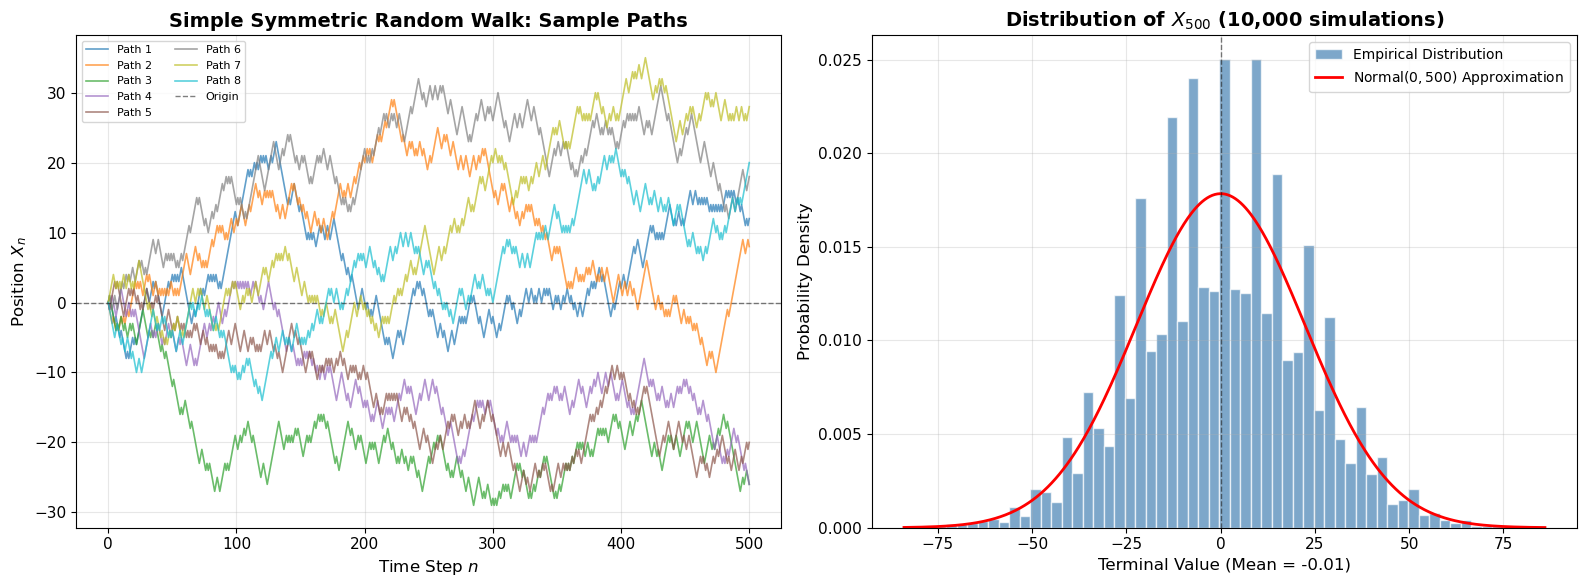

Empirical mean at n=500: -0.0126
Empirical variance at n=500: 492.8874
Theoretical variance: 500


In [8]:
# ============================================================
# Visualization: Multiple Random Walk Paths
# ============================================================

np.random.seed(42)

n_steps = 500
n_paths = 8

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Multiple sample paths ---
ax1 = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, n_paths))

all_walks = []
for i in range(n_paths):
    increments = np.random.choice([-1, 1], size=n_steps)
    walk = np.concatenate([[0], np.cumsum(increments)])
    all_walks.append(walk)
    ax1.plot(range(n_steps + 1), walk, color=colors[i], alpha=0.7, linewidth=1.2,
             label=rf'Path {i+1}')

ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Origin')
ax1.set_title('Simple Symmetric Random Walk: Sample Paths', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time Step $n$', fontsize=12)
ax1.set_ylabel('Position $X_n$', fontsize=12)
ax1.legend(loc='upper left', fontsize=8, ncol=2)

# --- Right: Distribution at terminal time ---
ax2 = axes[1]
n_simulations = 10000
terminal_values = []

for _ in range(n_simulations):
    increments = np.random.choice([-1, 1], size=n_steps)
    terminal_values.append(np.sum(increments))

terminal_values = np.array(terminal_values)

# Histogram
counts, bins, patches = ax2.hist(terminal_values, bins=61, density=True,
                                  color='steelblue', edgecolor='white', alpha=0.7,
                                  label='Empirical Distribution')

# Theoretical: X_n ~ approximately Normal(0, n) by CLT
x_theory = np.linspace(terminal_values.min(), terminal_values.max(), 500)
sigma = np.sqrt(n_steps)
y_theory = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x_theory**2 / (2 * sigma**2))
ax2.plot(x_theory, y_theory, 'r-', linewidth=2, label=rf'Normal$(0, {n_steps})$ Approximation')

ax2.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title(rf'Distribution of $X_{{{n_steps}}}$ ({n_simulations:,} simulations)', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'Terminal Value (Mean = {np.mean(terminal_values):.2f})', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Empirical mean at n={n_steps}: {np.mean(terminal_values):.4f}")
print(f"Empirical variance at n={n_steps}: {np.var(terminal_values):.4f}")
print(f"Theoretical variance: {n_steps}")


### Quadratic Variation of the Random Walk

An important quantity for martingales is the **quadratic variation**:

$$[X]_n = \sum_{i=1}^{n} (X_i - X_{i-1})^2 = \sum_{i=1}^{n} \xi_i^2 = n$$

Since $\xi_i^2 = 1$ always, the quadratic variation grows **deterministically** as $[X]_n = n$.

This is in contrast to the **variance** of $X_n$, which also equals $n$:

$$\text{Var}(X_n) = \mathbb{E}[X_n^2] - \mathbb{E}[X_n]^2 = n$$

For a general martingale, $\mathbb{E}[[X]_n] = \mathbb{E}[X_n^2] - \mathbb{E}[X_0^2]$.


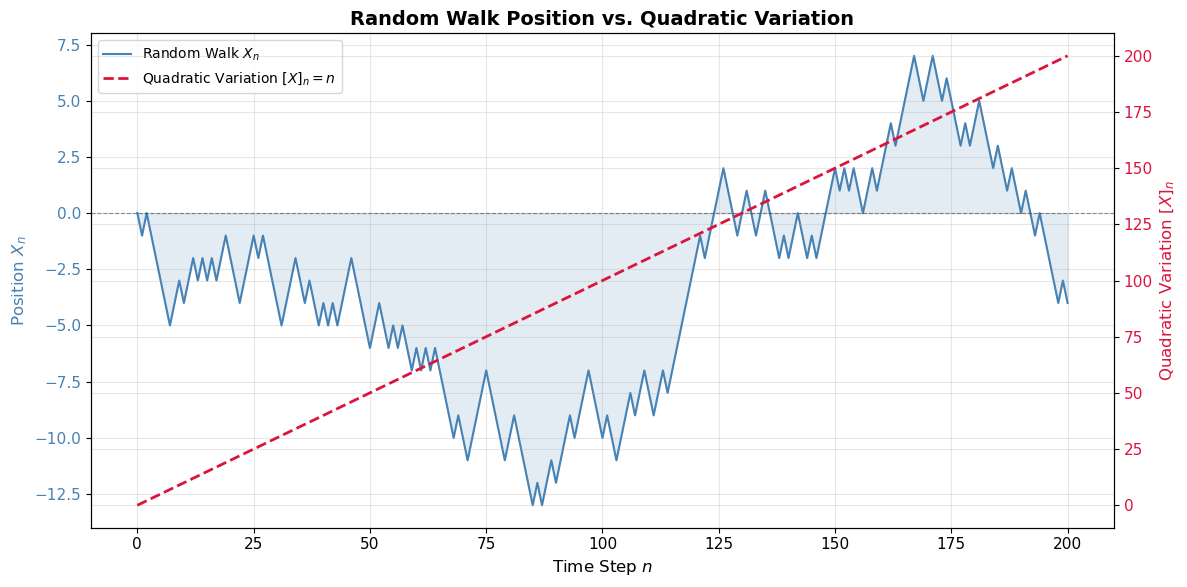

In [9]:
# ============================================================
# Visualization: Quadratic Variation vs. Path Position
# ============================================================

np.random.seed(123)
n_steps = 200

increments = np.random.choice([-1, 1], size=n_steps)
walk = np.concatenate([[0], np.cumsum(increments)])
quad_var = np.arange(n_steps + 1)  # [X]_n = n

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the random walk
color_walk = 'steelblue'
ax1.plot(range(n_steps + 1), walk, color=color_walk, linewidth=1.5, label='Random Walk $X_n$')
ax1.fill_between(range(n_steps + 1), walk, 0, alpha=0.15, color=color_walk)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax1.set_xlabel('Time Step $n$', fontsize=12)
ax1.set_ylabel('Position $X_n$', color=color_walk, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_walk)

# Secondary axis for quadratic variation
ax2 = ax1.twinx()
color_qv = 'crimson'
ax2.plot(range(n_steps + 1), quad_var, color=color_qv, linewidth=2, linestyle='--',
         label='Quadratic Variation $[X]_n = n$')
ax2.set_ylabel('Quadratic Variation $[X]_n$', color=color_qv, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_qv)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_title('Random Walk Position vs. Quadratic Variation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## **3. The Martingale Betting Strategy**

### Historical Context

The term **martingale** originates from 18th-century French gambling. The strategy is simple:

> After every loss, **double your bet**. When you finally win, you recover all previous losses plus win a profit equal to your original stake.

### Mathematical Formulation

Let $\xi_1, \xi_2, \ldots$ be i.i.d. with $\mathbb{P}(\xi_i = +1) = \mathbb{P}(\xi_i = -1) = \frac{1}{2}$, where $+1$ means "win" and $-1$ means "lose."

At round $n$, bet $B_n$ dollars, where:

$$B_1 = 1, \quad B_{n+1} = \begin{cases} 2B_n & \text{if } \xi_n = -1 \\ 1 & \text{if } \xi_n = +1 \end{cases}$$

Your wealth after $n$ rounds is:

$$W_n = W_0 + \sum_{i=1}^{n} B_i \xi_i$$

### The Catch: It is STILL a Martingale

Despite the doubling strategy, $(W_n)$ remains a martingale because each bet is **fair** ($\mathbb{E}[\xi_i] = 0$). The strategy cannot change the expected value.

The apparent paradox is resolved by noting:
- With probability 1, you will eventually win and gain $+1$
- But with small probability, you experience a catastrophic streak of losses
- The expected loss in those rare cases exactly cancels the frequent small gains
- 

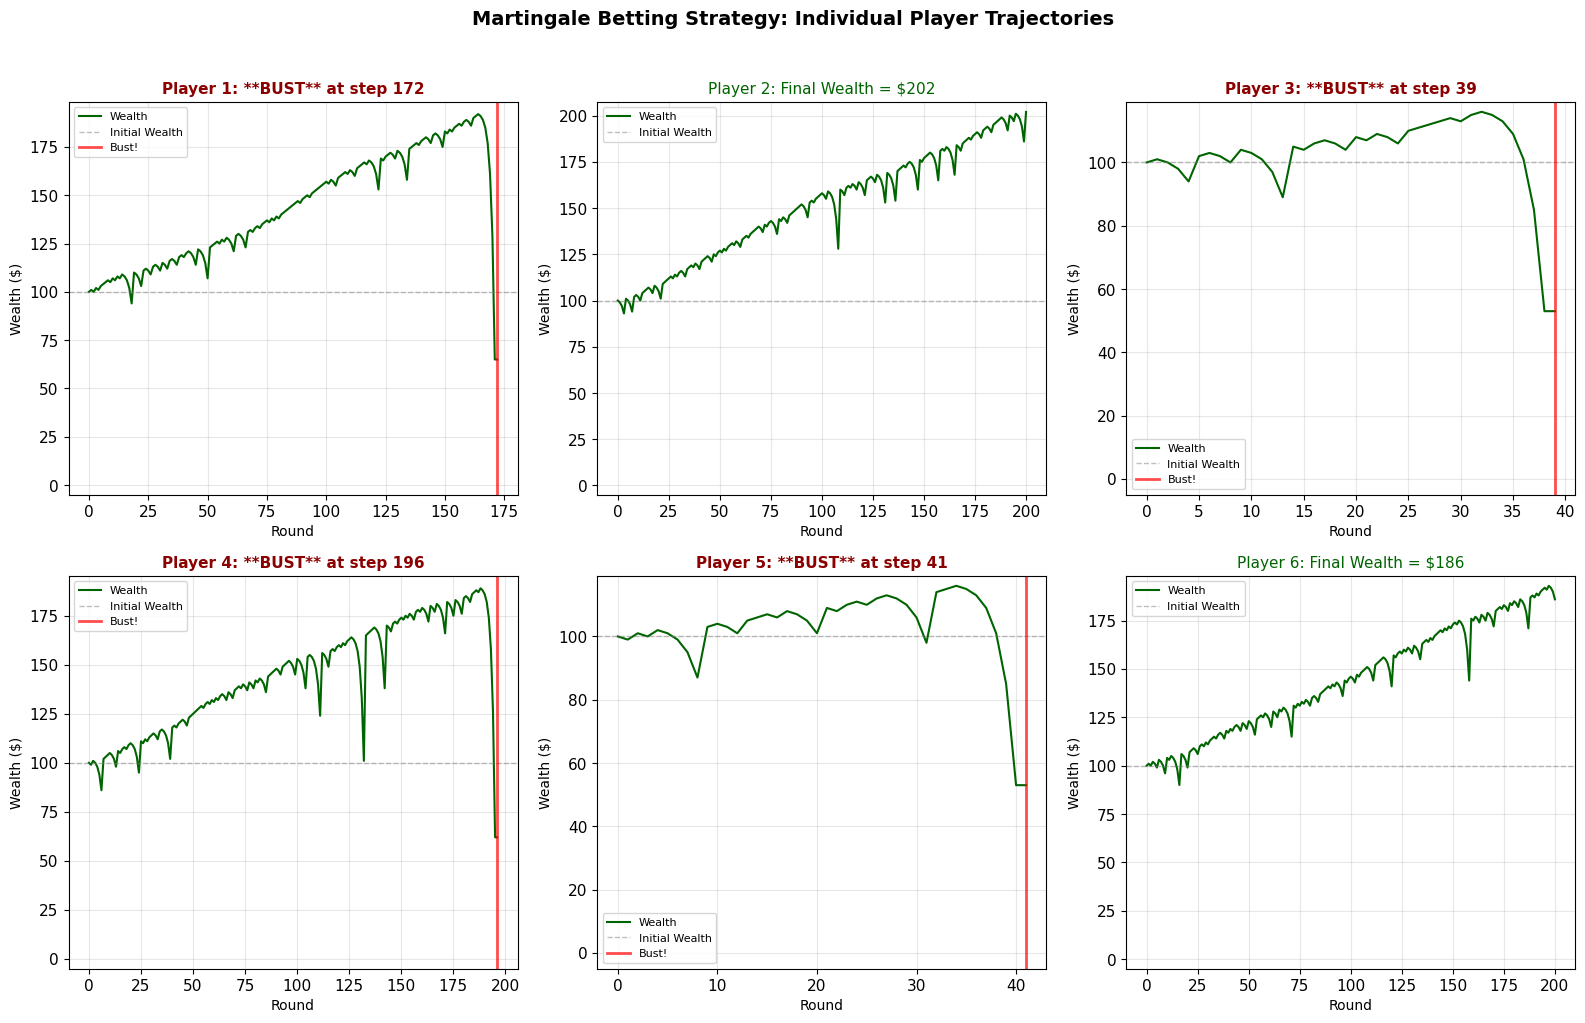

In [10]:
# ============================================================
# Visualization: Martingale Betting Strategy (Individual)
# ============================================================

np.random.seed(7)

def simulate_martingale_betting(n_rounds, max_bet=None, initial_wealth=100):
    """
    Simulate the martingale betting strategy.
    Returns: wealth trajectory, bet sizes, and whether bust occurred.
    """
    wealth = [initial_wealth]
    bets = [1]
    current_bet = 1
    current_wealth = initial_wealth
    bust = False
    
    for _ in range(n_rounds):
        if current_wealth < current_bet:
            bust = True
            wealth.append(current_wealth)
            bets.append(current_bet)
            break
        
        outcome = np.random.choice([-1, 1])  # -1 = lose, +1 = win
        current_wealth += outcome * current_bet
        wealth.append(current_wealth)
        
        if outcome == 1:
            current_bet = 1  # Reset to base bet after win
        else:
            current_bet *= 2  # Double after loss
            if max_bet is not None:
                current_bet = min(current_bet, max_bet)
        
        bets.append(current_bet)
    
    return np.array(wealth), np.array(bets), bust


# Simulate multiple players
n_players = 6
n_rounds = 200
initial_wealth = 100

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i in range(n_players):
    wealth, bets, bust = simulate_martingale_betting(n_rounds, initial_wealth=initial_wealth)
    
    ax = axes[i]
    steps = len(wealth)
    
    # Plot wealth
    ax.plot(range(steps), wealth, color='darkgreen', linewidth=1.5, label='Wealth')
    ax.axhline(y=initial_wealth, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Wealth')
    
    if bust:
        ax.axvline(x=steps-1, color='red', linestyle='-', linewidth=2, alpha=0.7, label='Bust!')
        ax.set_title(rf'Player {i+1}: **BUST** at step {steps-1}', fontsize=11, color='darkred', fontweight='bold')
    else:
        ax.set_title(rf'Player {i+1}: Final Wealth = ${wealth[-1]:.0f}', fontsize=11, color='darkgreen')
    
    ax.set_xlabel('Round', fontsize=10)
    ax.set_ylabel('Wealth ($)', fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.set_ylim(bottom=-5)

plt.suptitle('Martingale Betting Strategy: Individual Player Trajectories', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


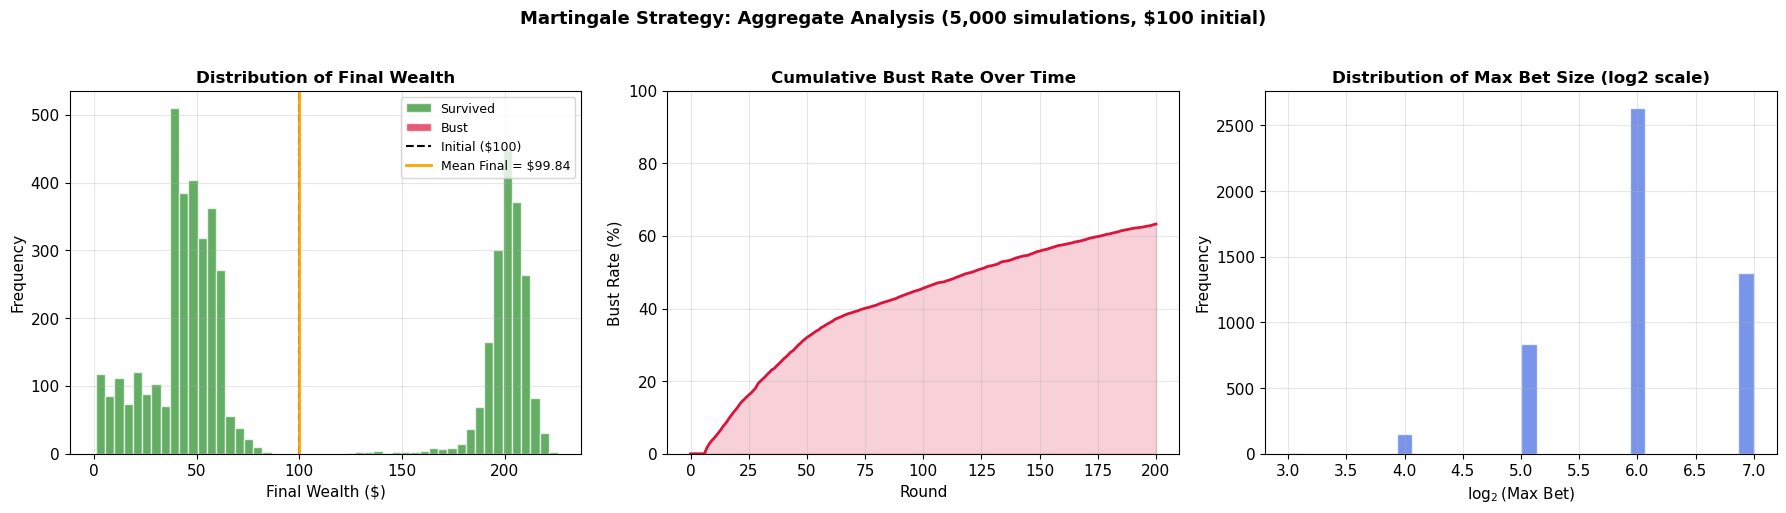

Bust rate after 200 rounds: 63.30%
Mean final wealth: $99.84
Median final wealth: $56.00
Probability of ending above initial: 36.56%


In [11]:
# ============================================================
# Aggregate Analysis: Many Players
# ============================================================

np.random.seed(99)
n_simulations = 5000
n_rounds = 200
initial_wealth = 100

final_wealths = []
bust_counts = []
min_wealths = []

for _ in range(n_simulations):
    wealth, bets, bust = simulate_martingale_betting(n_rounds, initial_wealth=initial_wealth)
    final_wealths.append(wealth[-1])
    bust_counts.append(1 if bust else 0)
    min_wealths.append(np.min(wealth))

final_wealths = np.array(final_wealths)
bust_rate = np.mean(bust_counts)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Histogram of final wealth ---
ax1 = axes[0]
non_bust = final_wealths[final_wealths > 0]
bust = final_wealths[final_wealths <= 0]

ax1.hist(non_bust, bins=50, color='forestgreen', edgecolor='white', alpha=0.7, label='Survived')
if len(bust) > 0:
    ax1.hist(bust, bins=10, color='crimson', edgecolor='white', alpha=0.7, label='Bust')

ax1.axvline(x=initial_wealth, color='black', linestyle='--', linewidth=1.5, label=rf'Initial (${initial_wealth})')
ax1.axvline(x=np.mean(final_wealths), color='orange', linestyle='-', linewidth=2,
            label=rf'Mean Final = ${np.mean(final_wealths):.2f}')
ax1.set_title('Distribution of Final Wealth', fontsize=12, fontweight='bold')
ax1.set_xlabel('Final Wealth ($)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.legend(fontsize=9)

# --- Plot 2: Bust rate over rounds ---
ax2 = axes[1]
np.random.seed(99)
bust_by_round = np.zeros(n_rounds + 1)

for _ in range(n_simulations):
    wealth, bets, bust = simulate_martingale_betting(n_rounds, initial_wealth=initial_wealth)
    if bust:
        bust_step = len(wealth) - 1
        bust_by_round[bust_step:] += 1

cumulative_bust_rate = bust_by_round / n_simulations
ax2.plot(range(n_rounds + 1), cumulative_bust_rate * 100, color='crimson', linewidth=2)
ax2.fill_between(range(n_rounds + 1), cumulative_bust_rate * 100, 0, alpha=0.2, color='crimson')
ax2.set_title('Cumulative Bust Rate Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Round', fontsize=11)
ax2.set_ylabel('Bust Rate (%)', fontsize=11)
ax2.set_ylim(0, 100)

# --- Plot 3: Max bet size distribution ---
ax3 = axes[2]
np.random.seed(99)
max_bets = []
for _ in range(n_simulations):
    wealth, bets, bust = simulate_martingale_betting(n_rounds, initial_wealth=initial_wealth)
    max_bets.append(np.max(bets))

max_bets = np.array(max_bets)
ax3.hist(np.log2(max_bets), bins=30, color='royalblue', edgecolor='white', alpha=0.7)
ax3.set_title('Distribution of Max Bet Size (log2 scale)', fontsize=12, fontweight='bold')
ax3.set_xlabel(r'$\log_2(\text{Max Bet})$', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)

plt.suptitle(rf'Martingale Strategy: Aggregate Analysis ({n_simulations:,} simulations, ${initial_wealth} initial)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Bust rate after {n_rounds} rounds: {bust_rate*100:.2f}%")
print(f"Mean final wealth: ${np.mean(final_wealths):.2f}")
print(f"Median final wealth: ${np.median(final_wealths):.2f}")
print(f"Probability of ending above initial: {np.mean(final_wealths > initial_wealth)*100:.2f}%")


---
## **4. Optional Stopping Theorem (OST)**

### The Core Question

If $(X_n)$ is a martingale and $\tau$ is a **stopping time** (a random time whose occurrence can be determined by observing the process up to that time), when does:

$$\mathbb{E}[X_\tau] = \mathbb{E}[X_0] \quad ?$$

This is the **Optional Stopping Theorem** — it tells us when we cannot beat a fair game by choosing when to stop.

### Formal Statement

Let $(X_n)_{n \geq 0}$ be a martingale and $\tau$ a stopping time. Then $\mathbb{E}[X_\tau] = \mathbb{E}[X_0]$ **if any** of the following holds:

1. **Bounded time:** $\tau \leq N$ almost surely for some finite $N$
2. **Bounded increments:** $|X_{n+1} - X_n| \leq K$ for all $n$, and $\mathbb{E}[\tau] < \infty$
3. **Uniform integrability:** The family $(X_{n \wedge \tau})_{n \geq 0}$ is uniformly integrable

### Counterexample: The Martingale Betting Strategy

Let $\tau$ be the first time the gambler wins (returns to profit). Then $\mathbb{E}[\tau] < \infty$, but the increments are **not bounded** (bets can grow arbitrarily large). Thus OST **does not apply**, and indeed $\mathbb{E}[W_\tau] \neq \mathbb{E}[W_0]$ in general.

### Visual Demonstration: Stopping at a Boundary

Consider a random walk stopped when it hits either $+a$ or $-b$. Let $\tau = \min\{n : X_n = +a \text{ or } X_n = -b\}$. Since $\tau$ is bounded in expectation and increments are bounded, OST applies:

$$\mathbb{E}[X_\tau] = 0 = a \cdot \mathbb{P}(X_\tau = a) + (-b) \cdot \mathbb{P}(X_\tau = -b)$$

Solving gives the **gambler's ruin probability**:

$$\mathbb{P}(X_\tau = a) = \frac{b}{a + b}, \quad \mathbb{P}(X_\tau = -b) = \frac{a}{a + b}$$


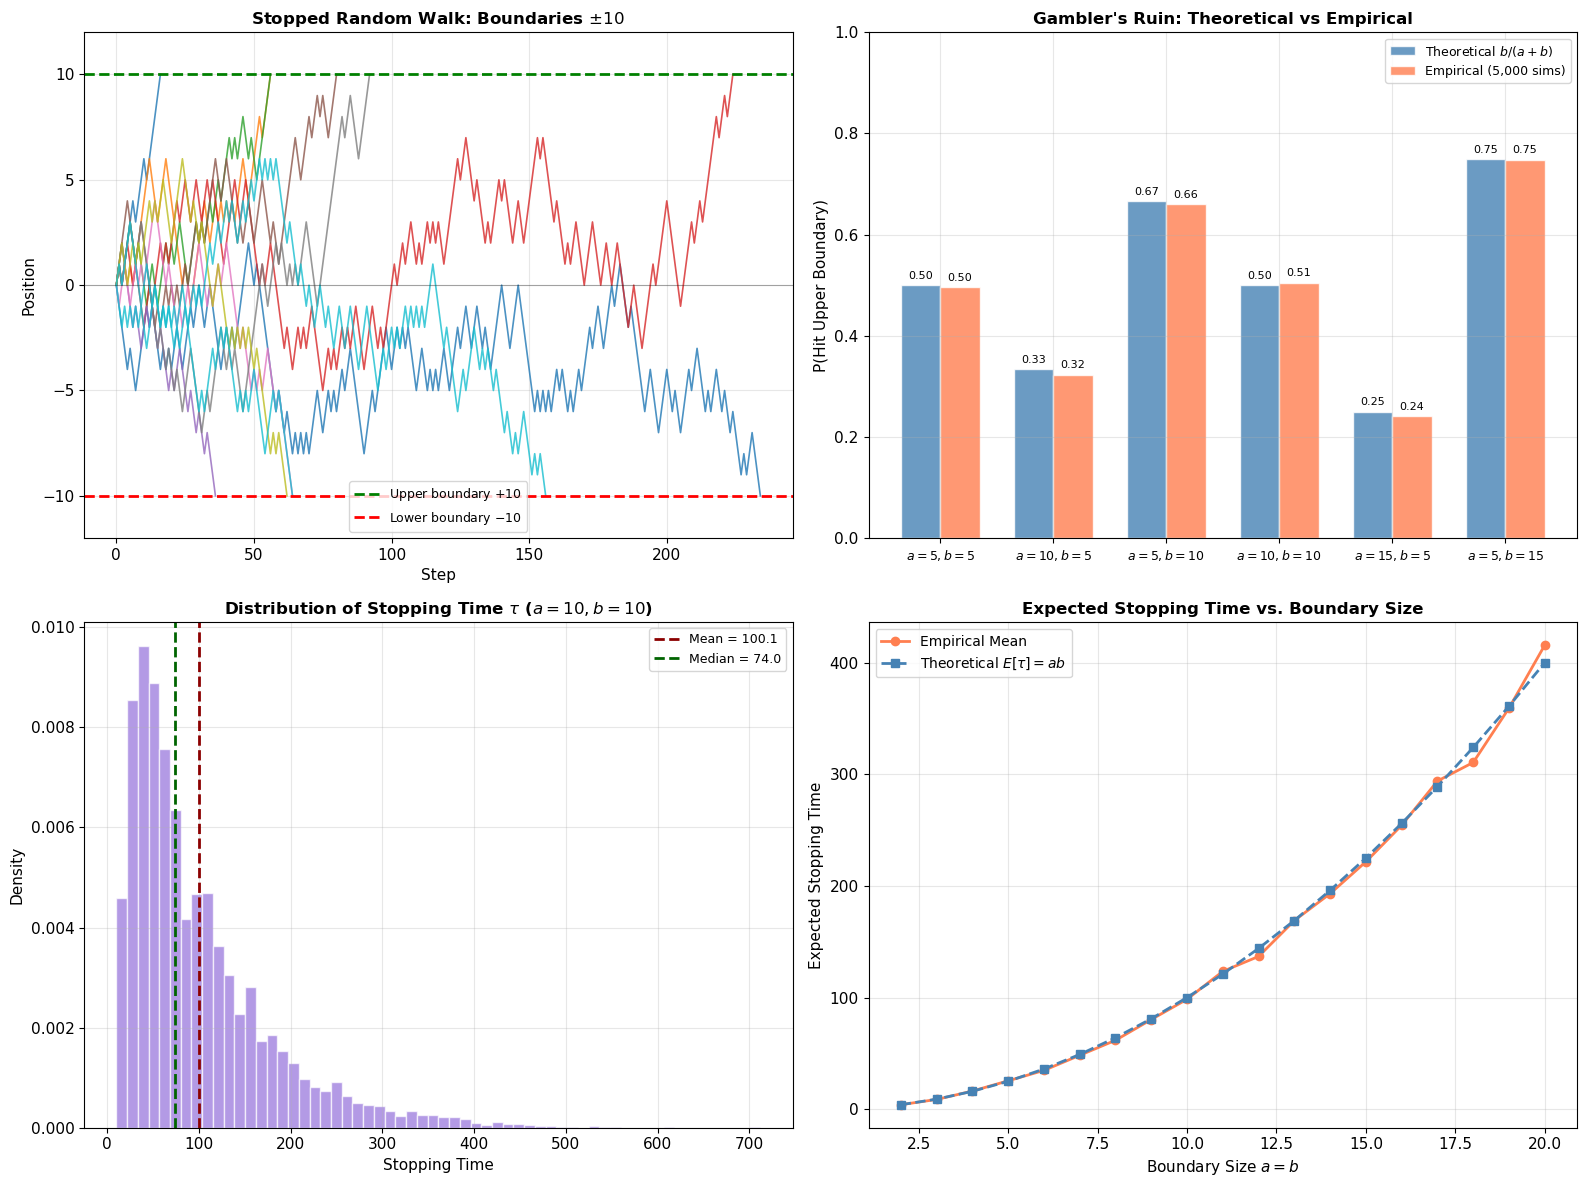

Theoretical P(hit +10) = 0.5000
Theoretical P(hit -10) = 0.5000
Theoretical E[tau] for a=b=10: 100


In [12]:
# ============================================================
# Visualization: Optional Stopping at Boundaries
# ============================================================

np.random.seed(2024)

def simulate_stopped_random_walk(a, b, max_steps=10000):
    """Simulate random walk stopped at +a or -b."""
    position = 0
    trajectory = [0]
    for step in range(max_steps):
        position += np.random.choice([-1, 1])
        trajectory.append(position)
        if position >= a or position <= -b:
            break
    return np.array(trajectory), position


a, b = 10, 10
n_paths = 12

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top Left: Sample paths with stopping boundaries ---
ax = axes[0, 0]
colors = plt.cm.tab10(np.linspace(0, 1, n_paths))

for i in range(n_paths):
    traj, final = simulate_stopped_random_walk(a, b)
    ax.plot(range(len(traj)), traj, color=colors[i], linewidth=1.2, alpha=0.8)

ax.axhline(y=a, color='green', linestyle='--', linewidth=2, label=rf'Upper boundary $+{a}$')
ax.axhline(y=-b, color='red', linestyle='--', linewidth=2, label=rf'Lower boundary $-{b}$')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax.set_title(rf'Stopped Random Walk: Boundaries $\pm{a}$', fontsize=12, fontweight='bold')
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Position', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(-b - 2, a + 2)

# --- Top Right: Empirical vs Theoretical hitting probabilities ---
ax = axes[0, 1]

boundary_pairs = [(5, 5), (10, 5), (5, 10), (10, 10), (15, 5), (5, 15)]
empirical_probs = []
theoretical_probs = []
labels = []

n_sims = 5000
for a_test, b_test in boundary_pairs:
    hits_upper = 0
    for _ in range(n_sims):
        _, final = simulate_stopped_random_walk(a_test, b_test)
        if final >= a_test:
            hits_upper += 1
    empirical_probs.append(hits_upper / n_sims)
    theoretical_probs.append(b_test / (a_test + b_test))
    labels.append(rf'$a={a_test}, b={b_test}$')

x_pos = np.arange(len(boundary_pairs))
width = 0.35

bars1 = ax.bar(x_pos - width/2, theoretical_probs, width, label='Theoretical $b/(a+b)$',
               color='steelblue', edgecolor='white', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, empirical_probs, width, label=f'Empirical ({n_sims:,} sims)',
               color='coral', edgecolor='white', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('P(Hit Upper Boundary)', fontsize=11)
ax.set_title("Gambler's Ruin: Theoretical vs Empirical", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

# --- Bottom Left: Distribution of stopping times ---
ax = axes[1, 0]

a_test, b_test = 10, 10
stopping_times = []
for _ in range(n_sims):
    traj, _ = simulate_stopped_random_walk(a_test, b_test)
    stopping_times.append(len(traj) - 1)

stopping_times = np.array(stopping_times)
ax.hist(stopping_times, bins=60, color='mediumpurple', edgecolor='white', alpha=0.7, density=True)
ax.axvline(x=np.mean(stopping_times), color='darkred', linestyle='--', linewidth=2,
           label=rf'Mean = {np.mean(stopping_times):.1f}')
ax.axvline(x=np.median(stopping_times), color='darkgreen', linestyle='--', linewidth=2,
           label=rf'Median = {np.median(stopping_times):.1f}')
ax.set_title(rf'Distribution of Stopping Time $\tau$ ($a={a_test}, b={b_test}$)', fontsize=12, fontweight='bold')
ax.set_xlabel('Stopping Time', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)

# --- Bottom Right: Expected stopping time vs boundary size ---
ax = axes[1, 1]

boundary_values = range(2, 21)
mean_stopping_times = []
theoretical_stopping = []

for m in boundary_values:
    times = []
    for _ in range(2000):
        traj, _ = simulate_stopped_random_walk(m, m)
        times.append(len(traj) - 1)
    mean_stopping_times.append(np.mean(times))
    theoretical_stopping.append(m * m)  # E[tau] = a*b for symmetric walk

ax.plot(boundary_values, mean_stopping_times, 'o-', color='coral', linewidth=2,
        markersize=6, label='Empirical Mean')
ax.plot(boundary_values, theoretical_stopping, 's--', color='steelblue', linewidth=2,
        markersize=6, label='Theoretical $E[\\tau] = ab$')
ax.set_title('Expected Stopping Time vs. Boundary Size', fontsize=12, fontweight='bold')
ax.set_xlabel('Boundary Size $a = b$', fontsize=11)
ax.set_ylabel('Expected Stopping Time', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Theoretical P(hit +{a}) = {b/(a+b):.4f}")
print(f"Theoretical P(hit -{b}) = {a/(a+b):.4f}")
print(f"Theoretical E[tau] for a=b={a_test}: {a_test * b_test}")


---
## **5. Martingale Convergence Theorem**

### The Theorem

Let $(X_n)_{n \geq 0}$ be a **supermartingale** (or submartingale) that is **bounded in $L^1$**:

$$\sup_{n \geq 0} \mathbb{E}[|X_n|] < \infty$$

Then there exists an integrable random variable $X_\infty$ such that:

$$X_n \xrightarrow{a.s.} X_\infty \quad \text{as } n \to \infty$$

For a **martingale**, boundedness in $L^1$ is equivalent to $\sup_n \mathbb{E}[|X_n|] < \infty$, which holds if $\sup_n \mathbb{E}[X_n^+] < \infty$ or $\sup_n \mathbb{E}[X_n^-] < \infty$.

### Key Implications

1. **Non-negative martingales always converge** (since $\mathbb{E}[|X_n|] = \mathbb{E}[X_n] = \mathbb{E}[X_0]$)
2. **Bounded martingales always converge**
3. The simple symmetric random walk **does NOT converge** because $\mathbb{E}[|X_n|] \sim \sqrt{2n/\pi} \to \infty$

### Example: Product Martingale

Let $Y_1, Y_2, \ldots$ be i.i.d. with $\mathbb{E}[Y_i] = 1$. Define:

$$M_n = \prod_{i=1}^{n} Y_i$$

Then $(M_n)$ is a non-negative martingale, so $M_n \to M_\infty$ almost surely.

If $\mathbb{P}(Y_i = 0) > 0$, then $M_\infty = 0$ with positive probability.

If $Y_i \sim \text{Uniform}(0, 2)$, then $M_n \to 0$ almost surely (since $\mathbb{E}[\log Y_i] < 0$).


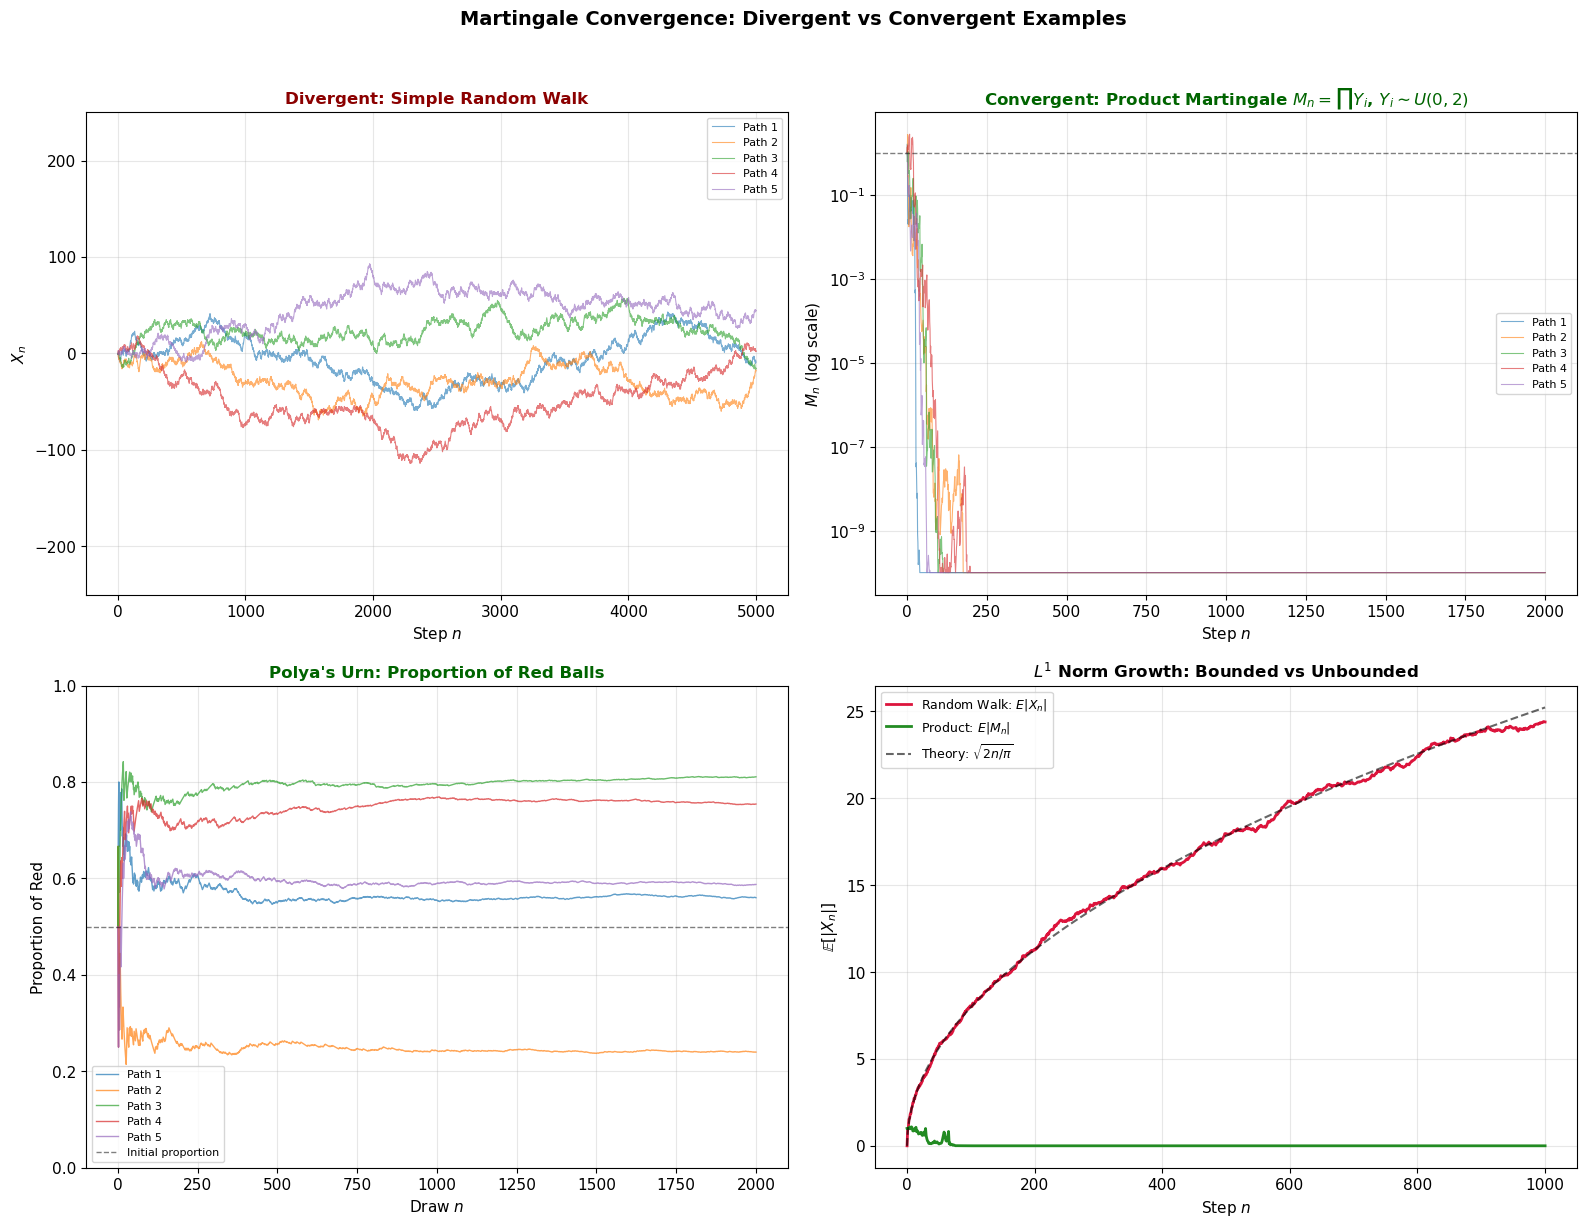

In [13]:
# ============================================================
# Visualization: Martingale Convergence Examples
# ============================================================

np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top Left: Non-converging (Random Walk) ---
ax = axes[0, 0]
n_steps = 5000
for i in range(5):
    increments = np.random.choice([-1, 1], size=n_steps)
    walk = np.concatenate([[0], np.cumsum(increments)])
    ax.plot(range(n_steps + 1), walk, alpha=0.6, linewidth=0.8, label=rf'Path {i+1}')
ax.set_title('Divergent: Simple Random Walk', fontsize=12, fontweight='bold', color='darkred')
ax.set_xlabel('Step $n$', fontsize=11)
ax.set_ylabel('$X_n$', fontsize=11)
ax.legend(fontsize=8)
ax.set_ylim(-250, 250)

# --- Top Right: Convergent Product Martingale ---
ax = axes[0, 1]
n_steps = 2000
for i in range(5):
    Y = np.random.uniform(0, 2, size=n_steps)
    M = np.concatenate([[1], np.cumprod(Y)])
    # Clip for visualization
    M_clipped = np.clip(M, 1e-10, 1e6)
    ax.semilogy(range(n_steps + 1), M_clipped, alpha=0.6, linewidth=0.8, label=rf'Path {i+1}')
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title(r'Convergent: Product Martingale $M_n = \prod Y_i$, $Y_i \sim U(0,2)$', fontsize=12, fontweight='bold', color='darkgreen')
ax.set_xlabel('Step $n$', fontsize=11)
ax.set_ylabel('$M_n$ (log scale)', fontsize=11)
ax.legend(fontsize=8)

# --- Bottom Left: Bounded Martingale (Polya's Urn) ---
ax = axes[1, 0]
n_steps = 2000
n_paths = 5

for i in range(n_paths):
    red = 1
    blue = 1
    proportion = [red / (red + blue)]
    for _ in range(n_steps):
        if np.random.random() < red / (red + blue):
            red += 1
        else:
            blue += 1
        proportion.append(red / (red + blue))
    ax.plot(range(n_steps + 1), proportion, alpha=0.7, linewidth=1, label=rf'Path {i+1}')
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Initial proportion')
ax.set_title(r"Polya's Urn: Proportion of Red Balls", fontsize=12, fontweight='bold', color='darkgreen')
ax.set_xlabel('Draw $n$', fontsize=11)
ax.set_ylabel('Proportion of Red', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# --- Bottom Right: L1 norm growth comparison ---
ax = axes[1, 1]
n_steps = 1000
n_sims = 500

# Random walk L1 norm
rw_l1 = []
for _ in range(n_sims):
    increments = np.random.choice([-1, 1], size=n_steps)
    walk = np.concatenate([[0], np.cumsum(increments)])
    rw_l1.append(np.abs(walk))
rw_l1 = np.array(rw_l1)
rw_mean_l1 = np.mean(rw_l1, axis=0)

# Product martingale L1 norm (bounded!)
prod_l1 = []
for _ in range(n_sims):
    Y = np.random.uniform(0, 2, size=n_steps)
    M = np.concatenate([[1], np.cumprod(Y)])
    prod_l1.append(np.abs(M))
prod_l1 = np.array(prod_l1)
prod_mean_l1 = np.mean(prod_l1, axis=0)

ax.plot(range(n_steps + 1), rw_mean_l1, color='crimson', linewidth=2, label='Random Walk: $E|X_n|$')
ax.plot(range(n_steps + 1), prod_mean_l1, color='forestgreen', linewidth=2, label='Product: $E|M_n|$')

# Theoretical sqrt curve for random walk
t = np.arange(n_steps + 1)
theoretical = np.sqrt(2 * t / np.pi)
theoretical[0] = 0
ax.plot(t, theoretical, 'k--', linewidth=1.5, alpha=0.6, label=r'Theory: $\sqrt{2n/\pi}$')

ax.set_title(r'$L^1$ Norm Growth: Bounded vs Unbounded', fontsize=12, fontweight='bold')
ax.set_xlabel('Step $n$', fontsize=11)
ax.set_ylabel(r'$\mathbb{E}[|X_n|]$', fontsize=11)
ax.legend(fontsize=9)

plt.suptitle('Martingale Convergence: Divergent vs Convergent Examples', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## **6. Doob's Decomposition Theorem**

### The Theorem

Any **adapted integrable process** $(X_n)_{n \geq 0}$ can be uniquely decomposed as:

$$X_n = M_n + A_n$$

where:
- $(M_n)$ is a **martingale** with $M_0 = X_0$
- $(A_n)$ is a **predictable process** with $A_0 = 0$

The predictable component is given by:

$$A_n = \sum_{k=1}^{n} \mathbb{E}[X_k - X_{k-1} \mid \mathcal{F}_{k-1}]$$

and the martingale component by:

$$M_n = X_n - A_n$$

### Interpretation

- If $(X_n)$ is already a martingale, then $A_n = 0$ and $M_n = X_n$
- If $(X_n)$ is a submartingale, then $A_n$ is **increasing** (predictable upward drift)
- If $(X_n)$ is a supermartingale, then $A_n$ is **decreasing** (predictable downward drift)

### Example: Biased Random Walk

Let $\xi_i$ be i.i.d. with $\mathbb{P}(\xi_i = +1) = p$ and $\mathbb{P}(\xi_i = -1) = 1-p$, where $p \neq \frac{1}{2}$.

Define $X_n = \sum_{i=1}^n \xi_i$. Then:

$$\mathbb{E}[X_k - X_{k-1} \mid \mathcal{F}_{k-1}] = \mathbb{E}[\xi_k] = 2p - 1$$

So the predictable component is:

$$A_n = n(2p - 1)$$

And the martingale component is:

$$M_n = X_n - n(2p - 1) = \sum_{i=1}^n (\xi_i - (2p - 1))$$

This decomposes the biased walk into a **deterministic drift** plus **martingale noise**.


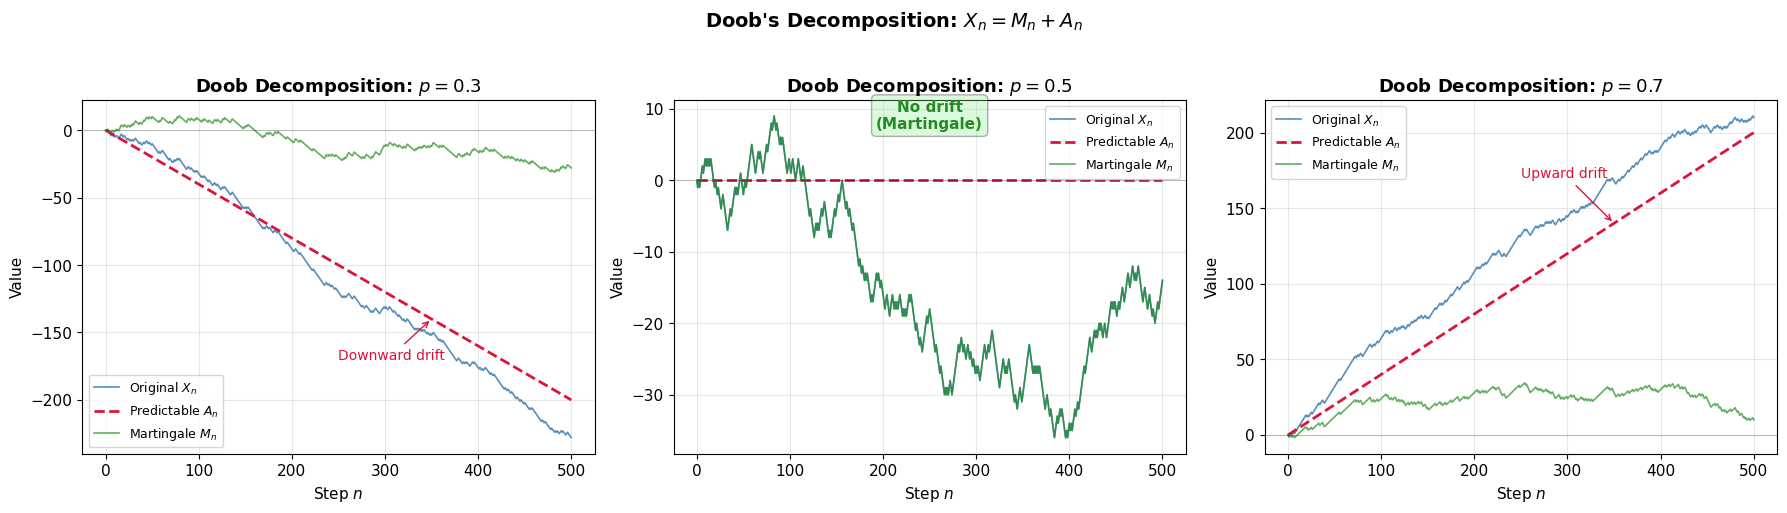

In [14]:
# ============================================================
# Visualization: Doob Decomposition of Biased Random Walk
# ============================================================

np.random.seed(55)

n_steps = 500
p_values = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, p in enumerate(p_values):
    ax = axes[idx]
    
    # Generate biased random walk
    increments = np.random.choice([-1, 1], size=n_steps, p=[1-p, p])
    X = np.concatenate([[0], np.cumsum(increments)])
    
    # Doob decomposition
    drift = 2 * p - 1
    A = np.concatenate([[0], np.arange(1, n_steps + 1) * drift])  # Predictable component
    M = X - A  # Martingale component
    
    # Plot
    ax.plot(range(n_steps + 1), X, color='steelblue', linewidth=1.2, alpha=0.9, label='Original $X_n$')
    ax.plot(range(n_steps + 1), A, color='crimson', linewidth=2, linestyle='--', label='Predictable $A_n$')
    ax.plot(range(n_steps + 1), M, color='forestgreen', linewidth=1.2, alpha=0.7, label='Martingale $M_n$')
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.set_title(rf'Doob Decomposition: $p = {p}$', fontsize=13, fontweight='bold')
    ax.set_xlabel('Step $n$', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.legend(fontsize=9, loc='best')
    
    # Add annotation for drift direction
    if p > 0.5:
        ax.annotate('Upward drift', xy=(n_steps*0.7, A[int(n_steps*0.7)]),
                    xytext=(n_steps*0.5, A[int(n_steps*0.7)] + 30),
                    arrowprops=dict(arrowstyle='->', color='crimson'),
                    fontsize=10, color='crimson')
    elif p < 0.5:
        ax.annotate('Downward drift', xy=(n_steps*0.7, A[int(n_steps*0.7)]),
                    xytext=(n_steps*0.5, A[int(n_steps*0.7)] - 30),
                    arrowprops=dict(arrowstyle='->', color='crimson'),
                    fontsize=10, color='crimson')
    else:
        ax.text(n_steps*0.5, X.max()*0.8, 'No drift\n(Martingale)',
                ha='center', fontsize=11, color='forestgreen', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.suptitle(r"Doob's Decomposition: $X_n = M_n + A_n$", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## **7. Summary & References**

### Key Takeaways

| Concept | Key Insight |
|---------|-------------|
| **Martingale** | Best prediction of future = present value; fair game |
| **Random Walk** | Canonical example; variance grows as $n$; does not converge |
| **Betting Strategy** | Doubling bets does not change expected value; high bust risk |
| **Optional Stopping** | Cannot beat fair game with bounded stopping rules |
| **Convergence** | Non-negative or bounded martingales converge a.s. |
| **Doob Decomposition** | Any process = martingale + predictable drift |

### Important Formulas

$$\text{Martingale Property:} \quad \mathbb{E}[X_{n+1} \mid \mathcal{F}_n] = X_n$$

$$\text{Gambler's Ruin:} \quad \mathbb{P}(\text{hit } +a) = \frac{b}{a+b}$$

$$\text{Doob Decomposition:} \quad X_n = M_n + A_n$$

$$\text{Quadratic Variation:} \quad [X]_n = \sum_{i=1}^n (X_i - X_{i-1})^2$$

### References

1. **Williams, D.** (1991). *Probability with Martingales*. Cambridge University Press. — The classic introductory text.
2. **Durrett, R.** (2019). *Probability: Theory and Examples* (5th ed.). Cambridge University Press. — Comprehensive graduate-level treatment.
3. **Karlin, S. & Taylor, H.M.** (1975). *A First Course in Stochastic Processes*. Academic Press. — Excellent for random walks and applications.
4. **Shreve, S.E.** (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*. Springer. — Martingales in financial context.

